## Контрольная работа 4 Вариант 1

In [89]:
import numpy as np
import matplotlib.pyplot as plt

### Задача 1 Численное дифференцирование (1.5 балла)

Для заданной функции $f(x)=\frac{x \cdot e^{-x}}{\sqrt{\left(x^2-1\right)}}$ на интервале $[2 ; 10]$ для нескольких шагов $h$
- Аналитически рассчитать производную 
- Вычислить и построить аппроксимацию производной используя аппроксимации левой, правой и центральной разностей, построить графики вместе с истинным ответом для одного из значений $h$
- Вычислить погрешность для каждой из аппроксимаций и построить её от шага $h$. Какие получились экспериментальные порядки аппроксимации?

In [90]:
def f_prime(x):
    
    return np.exp(-x)*(-x**3+x-1)/np.pow(x**2 - 1, 3/2)

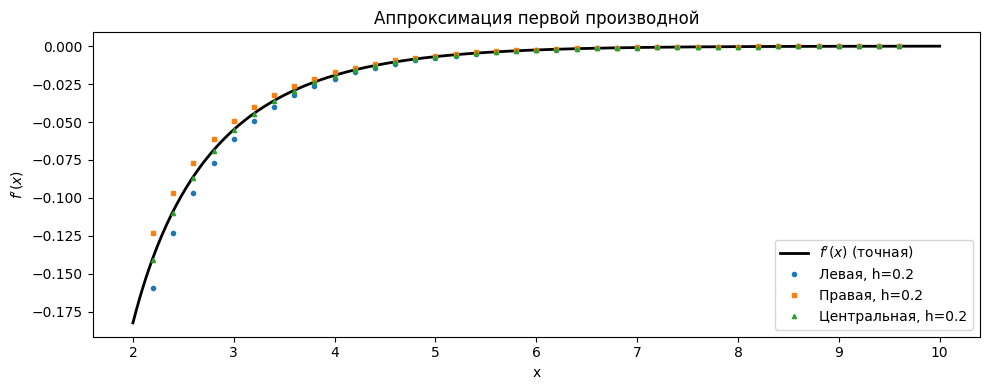

In [91]:
def f(x):
    return x * np.exp(-x) / np.sqrt(x**2 - 1)

a, b = 2.0, 10.0

def d_left(f, x, h):
    return (f(x) - f(x - h)) / h

def d_right(f, x, h):
    return (f(x + h) - f(x)) / h

def d_center(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

h_demo = 0.2
x_fine = np.linspace(a, b, 500)
x_pts = np.arange(a + h_demo, b - h_demo, h_demo)

plt.figure(figsize=(10, 4))
plt.plot(x_fine, f_prime(x_fine), 'k-', lw=2, label=r"$f^\prime(x)$ (точная)")
plt.plot(x_pts, d_left(f, x_pts, h_demo), 'o', ms=3, label=f"Левая, h={h_demo}")
plt.plot(x_pts, d_right(f, x_pts, h_demo), 's', ms=3, label=f"Правая, h={h_demo}")
plt.plot(x_pts, d_center(f, x_pts, h_demo), '^', ms=3, label=f"Центральная, h={h_demo}")
plt.xlabel("x"); plt.ylabel("$f'(x)$")
plt.legend()
plt.title("Аппроксимация первой производной")
plt.tight_layout(); plt.show()


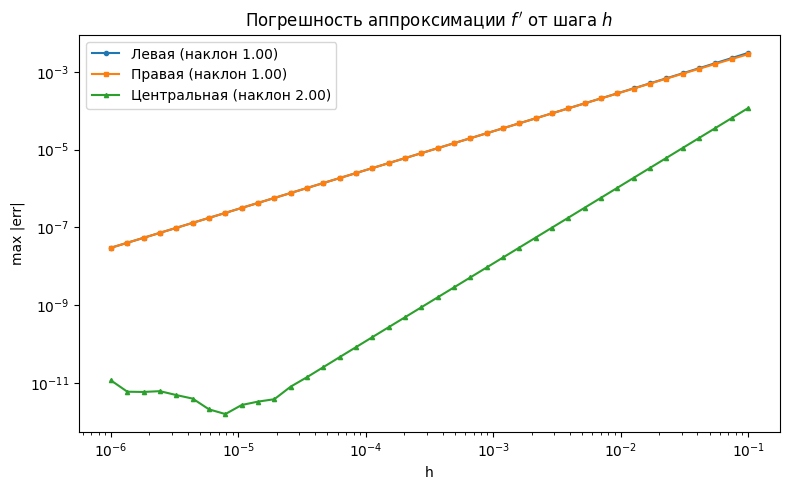

Экспериментальные порядки:
Левая разность:1.00
Правая разность:1.00
Центральная разность:2.00


In [92]:
H = np.logspace(-1, -6, 40)
err_l = np.zeros_like(H)
err_r = np.zeros_like(H)
err_c = np.zeros_like(H)

x_test = np.linspace(a + 1, b - 1, 300)
exact = f_prime(x_test)

for i, h in enumerate(H):
    err_l[i] = np.max(np.abs(d_left(f, x_test, h) - exact))
    err_r[i] = np.max(np.abs(d_right(f, x_test, h) - exact))
    err_c[i] = np.max(np.abs(d_center(f, x_test, h) - exact))

p_l = np.polyfit(np.log(H[:25]), np.log(err_l[:25]), 1)[0]
p_r = np.polyfit(np.log(H[:25]), np.log(err_r[:25]), 1)[0]
p_c = np.polyfit(np.log(H[:25]), np.log(err_c[:25]), 1)[0]

plt.figure(figsize=(8, 5))
plt.loglog(H, err_l, 'o-', ms=3, label=f"Левая (наклон {p_l:.2f})")
plt.loglog(H, err_r, 's-', ms=3, label=f"Правая (наклон {p_r:.2f})")
plt.loglog(H, err_c, '^-', ms=3, label=f"Центральная (наклон {p_c:.2f})")
plt.xlabel("h"); plt.ylabel("max |err|")
plt.legend()
plt.title(r"Погрешность аппроксимации $f^\prime$ от шага $h$")
plt.tight_layout(); plt.show()

print(f"Экспериментальные порядки:")
print(f"Левая разность:{p_l:.2f}")
print(f"Правая разность:{p_r:.2f}")
print(f"Центральная разность:{p_c:.2f}")


### Задача 2  Численное интегрирование (3 балла)

Вычислить интеграл $\int_0^{1} \cos \frac{\pi}{x} d x$ с точностью $5 \cdot 10^{-5}$ (Оценивать точность алгоритмом Рунге).

Функция $\cos(\pi/x)$ быстро осциллирует при $x \to 0^+$. Сделаем замену $x = 1/t$, $dx = -dt/t^2$:

$$J = \int_0^1 \cos\frac{\pi}{x}\,dx = \int_1^{\infty} \frac{\cos(\pi t)}{t^2}\,dt$$

Этот интеграл сходится и подынтегральная функция гладкая. Обрежем хвост:

$$\int_T^{\infty}\frac{\cos(\pi t)}{t^2}dt \leq \int_T^{\infty}\frac{dt}{t^2} = \frac{1}{T}$$

При $T = 10^5$ остаток $< 10^{-5}$, а на $[1, T]$ применим формулу Симпсона с оценкой Рунге.

In [93]:
from scipy.integrate import simpson

def g(t):
    return np.cos(np.pi * t) / t**2

eps_target = 5e-5
T = 100000

n = 2001
while True:
    t1 = np.linspace(1, T, n)
    t2 = np.linspace(1, T, 2 * n - 1)
    I_n = simpson(g(t1), x=t1)
    I_2n = simpson(g(t2), x=t2)
    runge_err = abs(I_2n - I_n) / 15
    if runge_err < eps_target / 2:
        break
    n = 2 * n - 1

J = I_2n

print(f"n точек: {2*n-1}")
print(f"J = {J:.8f}")
print(f"Оценка Рунге: {runge_err:.2e}")
print(f"Остаток хвоста 1/T = {1/T:.2e}")
print(f"Полная оценка погрешности: {runge_err + 1/T:.2e} < {eps_target}")

n точек: 1024001
J = -0.11675293
Оценка Рунге: 1.65e-05
Остаток хвоста 1/T = 1.00e-05
Полная оценка погрешности: 2.65e-05 < 5e-05


### Задача 3  Интерполяция (2 балла)

На отрезке $[2,5]$ для дробно-линейной функции $y(x)=\frac{x-3,5}{x+\sqrt{3}-3,5}$ построить  интерполяционный полином на сетке из __нулей__ полинома Чебышёва. Оценить погрешность данного метода интерполяции в зависимости от $n$ - число узлов Чебышева.

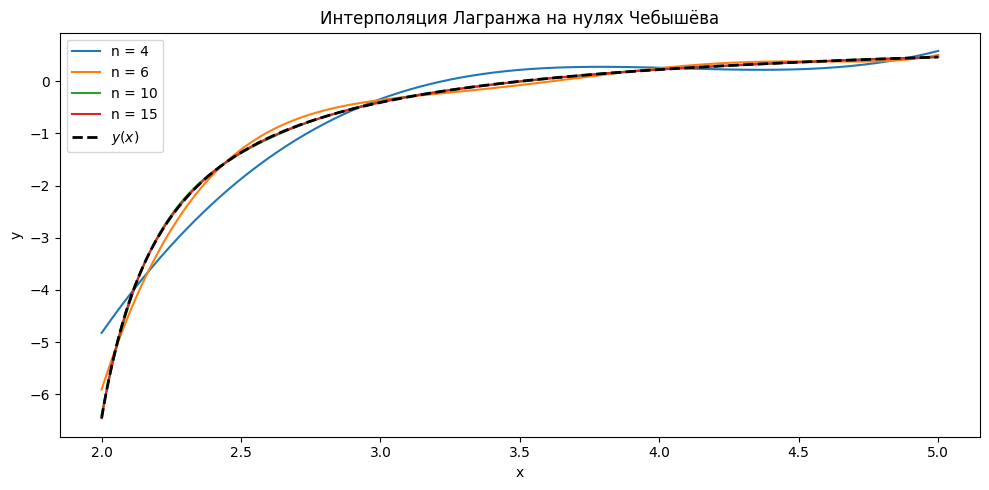

In [94]:
def y_func(x):
    return (x - 3.5) / (x + np.sqrt(3) - 3.5)

a_int, b_int = 2.0, 5.0

def cheb_zeros(n, a, b):
    k = np.arange(n)
    t = np.cos(np.pi * (2 * k + 1) / (2 * n))
    return (a + b) / 2 + (b - a) / 2 * t

def lagrange_interp(xk, yk, x):
    n = len(xk)
    result = np.zeros_like(x, dtype=float)
    for i in range(n):
        basis = np.ones_like(x, dtype=float)
        for j in range(n):
            if j != i:
                basis *= (x - xk[j]) / (xk[i] - xk[j])
        result += yk[i] * basis
    return result

x_fine = np.linspace(a_int, b_int, 1000)
y_fine = y_func(x_fine)

plt.figure(figsize=(10, 5))
for n in [4, 6, 10, 15]:
    xk = cheb_zeros(n, a_int, b_int)
    yk = y_func(xk)
    y_lag = lagrange_interp(xk, yk, x_fine)
    plt.plot(x_fine, y_lag, label=f"n = {n}")
plt.plot(x_fine, y_fine, 'k--', lw=2, label="$y(x)$")
plt.title("Интерполяция Лагранжа на нулях Чебышёва")
plt.legend(); plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout(); plt.show()

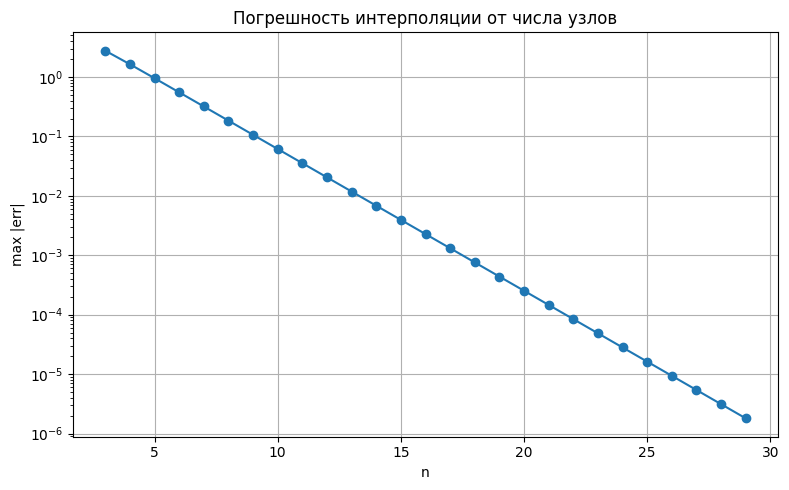

In [95]:
ns = np.arange(3, 30)
errors = []
for n in ns:
    xk = cheb_zeros(n, a_int, b_int)
    yk = y_func(xk)
    y_lag = lagrange_interp(xk, yk, x_fine)
    errors.append(np.max(np.abs(y_lag - y_fine)))

plt.figure(figsize=(8, 5))
plt.semilogy(ns, errors, 'o-')
plt.xlabel("n"); plt.ylabel("max |err|")
plt.title("Погрешность интерполяции от числа узлов")
plt.grid()
plt.tight_layout(); plt.show()

### Задача 4  Ряды (1 балл)

Вычислить сумму ряда

$$
\sum_{n=1}^{\infty} \frac{n^2+1}{n^4+n^2+1} \cdot (-1)^n
$$

с точностью $\varepsilon=10^{-6}$. Обоснуйте, почему исходная точность достигнута.

Применим метод Куммера с вспомогательным рядом $b_n = \frac{(-1)^n}{n^2}$, сумма которого:
$$\sum_{n=1}^{\infty}\frac{(-1)^{n-1}}{n^2} = \frac{\pi^2}{12} \implies \sum_{n=1}^{\infty}\frac{(-1)^{n}}{n^2} = -\frac{\pi^2}{12}$$

$$\gamma = \lim_{n \to \infty}\frac{a_n}{b_n} = \lim_{n \to \infty}\frac{(n^2+1)\cdot n^2}{n^4+n^2+1} = 1$$

Остаток $a_n - b_n = \left(\frac{n^2+1}{n^4+n^2+1} - \frac{1}{n^2}\right)(-1)^n$ убывает как $O(1/n^4)$. Тогда нам достаточно взять $n=30$ членов.

In [96]:
S1 = -np.pi**2 / 12

eps = 1e-6

S_corr = 0.0
N_kummer = 0
for n in range(1, 100000):
    a_n = (n**2 + 1) / (n**4 + n**2 + 1) * (-1)**n
    b_n = (-1)**n / n**2
    term = a_n - b_n
    S_corr += term
    if n > 1 and abs(term) < eps:
        N_kummer = n
        break

S_kummer = S1 + S_corr

S_direct = 0.0
N_direct = 0
for n in range(1, 10**7):
    term = (n**2 + 1) / (n**4 + n**2 + 1) * (-1)**n
    S_direct += term
    if n > 1 and abs(term) < eps:
        N_direct = n
        break

print(f"Метод Куммера: S = {S_kummer:.10f},  членов: {N_kummer}")
print(f"Прямое суммирование: S = {S_direct:.10f},  членов: {N_direct}")
print(f"|err| (с прямым суммированием) = {abs(S_kummer - S_direct):.2e}")

Метод Куммера: S = -0.5000003533,  членов: 10
Прямое суммирование: S = -0.4999995005,  членов: 1000
|err| (с прямым суммированием) = 8.53e-07


### Задача 5  Дискретное преобразование Фурье (1.5 балла)

Построить графики дискретного преобразования Фурье для

$$
x(k)=\left\{\begin{array}{c}
\cos \left(\frac{2 \pi}{N} k\right), \quad 0 \leq k \leq N-1, \\
0, \quad \text { при других } k .
\end{array}\right.
$$

при $N=16, \; 32, \; 64, \; 128$.

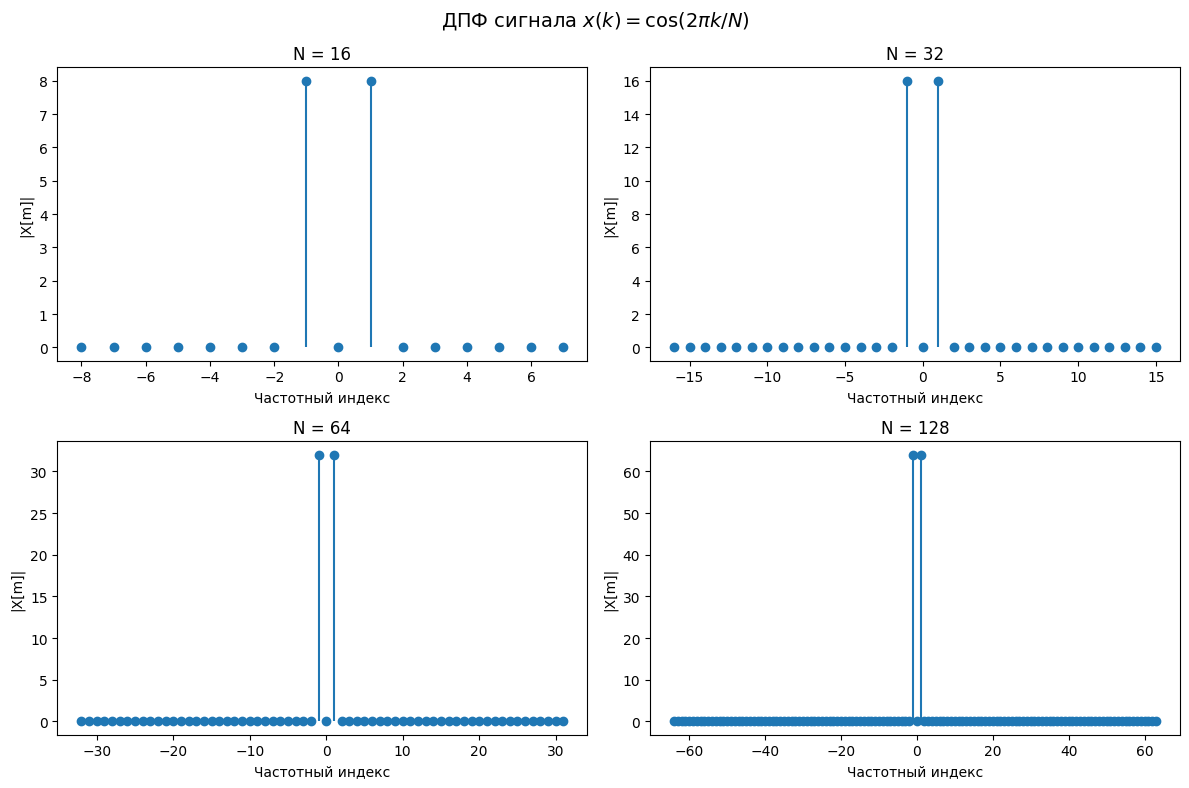

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, N in zip(axes.flat, [16, 32, 64, 128]):
    k = np.arange(N)
    x_k = np.cos(2 * np.pi * k / N)

    X = np.fft.fft(x_k)
    freqs = np.fft.fftfreq(N, d=1.0/N)

    ax.stem(freqs, np.abs(X), markerfmt='o', basefmt=' ')
    ax.set_title(f"N = {N}")
    ax.set_xlabel("Частотный индекс")
    ax.set_ylabel("|X[m]|")

plt.suptitle("ДПФ сигнала $x(k) = \\cos(2\\pi k / N)$", fontsize=14)
plt.tight_layout(); plt.show()

### Задача 6 Интерполяция (1.5 балла)

$f(x) = e^x$

1. Запишите значения $f(x)$ в узлах Чебышева.
2. Постройте интерполяционный многочлен в форме Лагранжа.
3. Преобразуйте задачу к тригонометрической интерполяции, найдите коэффициенты тригонометрического многочлена, соответствующего точной интерполяции по всем точкам.
4. Сравните графики обоих методов и постройте разницу между интерполяционными функциями.

In [98]:
n_cheb = 8
a_seg, b_seg = -1.0, 1.0

k_arr = np.arange(n_cheb)
t_nodes = np.cos(np.pi * (2 * k_arr + 1) / (2 * n_cheb))
f_nodes = np.exp(t_nodes)

print("Узлы Чебышёва и значения в них:")
for i in range(n_cheb):
    print(f"t_{i} = {t_nodes[i]:+.6f},  f(t_{i}) = {f_nodes[i]:.6f}")

Узлы Чебышёва и значения в них:
t_0 = +0.980785,  f(t_0) = 2.666549
t_1 = +0.831470,  f(t_1) = 2.296692
t_2 = +0.555570,  f(t_2) = 1.742935
t_3 = +0.195090,  f(t_3) = 1.215421
t_4 = -0.195090,  f(t_4) = 0.822760
t_5 = -0.555570,  f(t_5) = 0.573745
t_6 = -0.831470,  f(t_6) = 0.435409
t_7 = -0.980785,  f(t_7) = 0.375016


In [99]:
x_fine = np.linspace(a_seg, b_seg, 500)
y_exact = np.exp(x_fine)
y_lagrange = lagrange_interp(t_nodes, f_nodes, x_fine)

theta_nodes = np.arccos(t_nodes)
c = np.fft.rfft(f_nodes)

def trig_interp(theta, c_coeffs, N):
    result = np.zeros_like(theta)
    for m in range(len(c_coeffs)):
        if m == 0:
            result += c_coeffs[m].real / N
        elif m == N // 2 and N % 2 == 0:
            result += c_coeffs[m].real * np.cos(m * theta) / N
        else:
            result += 2 * (c_coeffs[m].real * np.cos(m * theta) - c_coeffs[m].imag * np.sin(m * theta)) / N
    return result

theta_fine = np.arccos(x_fine)
y_trig = trig_interp(theta_fine, c, n_cheb)

In [100]:
print("Коэффициенты тригонометрического многочлена (c_m):")
for m in range(len(c)):
    print(f"c_{m} = {c[m]/n_cheb:.8f}")

Коэффициенты тригонометрического многочлена (c_m):
c_0 = 1.26606588+0.00000000j
c_1 = 0.30848008-0.39001105j
c_2 = 0.16387078-0.15999991j
c_3 = 0.15246718-0.06312963j
c_4 = 0.15084744+0.00000000j


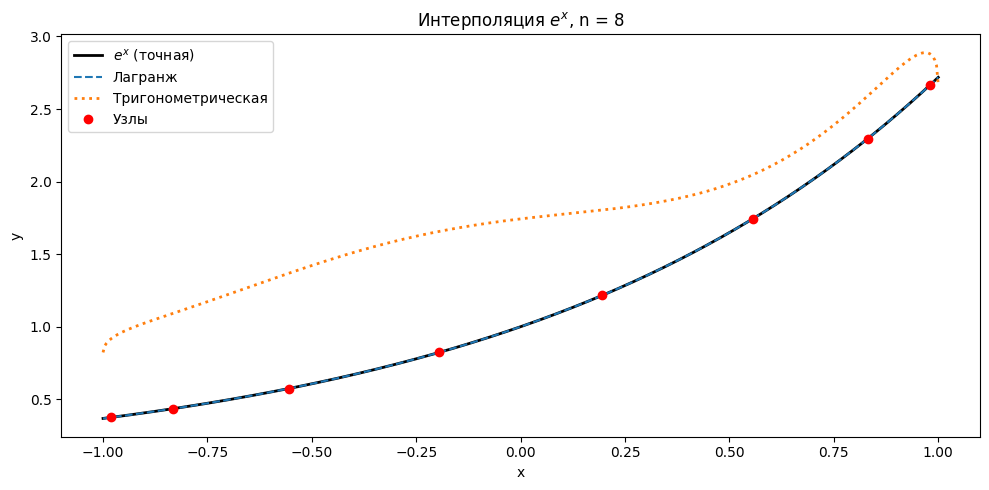

In [101]:
plt.figure(figsize=(10, 5))
plt.plot(x_fine, y_exact, 'k-', lw=2, label="$e^x$ (точная)")
plt.plot(x_fine, y_lagrange, '--', label="Лагранж")
plt.plot(x_fine, y_trig, ':', lw=2, label="Тригонометрическая")
plt.plot(t_nodes, f_nodes, 'ro', ms=6, zorder=5, label="Узлы")
plt.legend(); plt.title(f"Интерполяция $e^x$, n = {n_cheb}")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout(); plt.show()

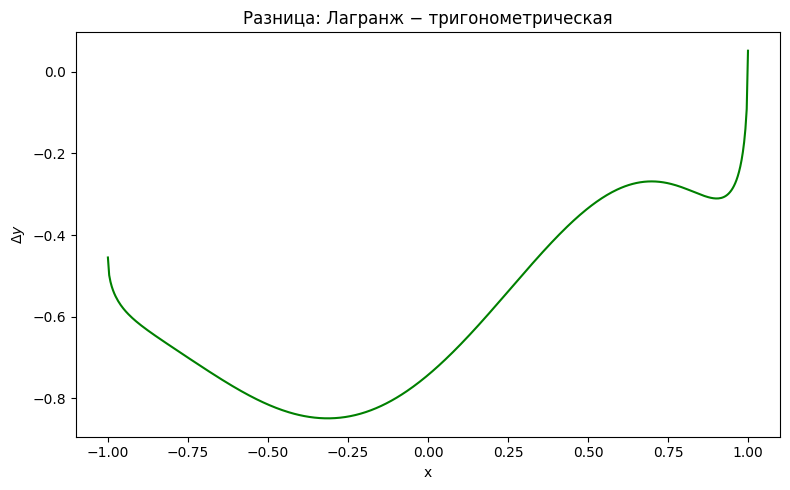

In [102]:
plt.figure(figsize=(8, 5))
plt.plot(x_fine, y_lagrange - y_trig, 'g-', lw=1.5)
plt.title("Разница: Лагранж − тригонометрическая")
plt.xlabel("x"); plt.ylabel("$\\Delta y$")
plt.ticklabel_format(style='sci', axis='y', scilimits=(-3, 3))
plt.tight_layout(); plt.show()

In [103]:
print(f"max |Лагранж − точная|:  {np.max(np.abs(y_lagrange - y_exact)):.2e}")
print(f"max |Триг. − точная|:    {np.max(np.abs(y_trig - y_exact)):.2e}")
print(f"max |Лагранж − Триг.|:   {np.max(np.abs(y_lagrange - y_trig)):.2e}")

max |Лагранж − точная|:  2.22e-07
max |Триг. − точная|:    8.49e-01
max |Лагранж − Триг.|:   8.49e-01
